In [26]:
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.utils import shuffle

### 3.3 単純パーセプトロン

In [3]:
class SimplePerceptron(object):
    """
    単純パーセプトロン
    """

    def __init__(self, input_dim: int) -> None:
        self.input_dim = input_dim
        self.w = np.random.normal(size=(input_dim,))
        self.b = 0.0

    def _step(self, x: np.ndarray) -> np.ndarray:
        return 1 * (x > 0)

    def forward(self, x: np.ndarray) -> np.ndarray:
        y = self._step(np.matmul(self.w, x) + self.b)
        return y

    def compute_deltas(self, x: np.ndarray, t: float) -> tuple[np.ndarray, float]:
        y = self.forward(x)
        delta = y - t
        dw = delta * x
        db = delta
        return dw, db

In [4]:
"""
1. データの準備
"""

np.random.seed(123)

d = 2
N = 20

mean = 5

# 第二項は各列の平均
x1 = np.random.randn(N // 2, d) + np.array([0, 0])
x2 = np.random.randn(N // 2, d) + np.array([mean, mean])

t1 = np.zeros(N // 2)
t2 = np.ones(N // 2)

# 行方向につなげてる
x = np.concatenate((x1, x2), axis=0)
t = np.concatenate((t1, t2))

"""
2. モデルの構築
"""
model = SimplePerceptron(input_dim=d)
"""
3. モデルの学習
"""


def compute_loss(dw: np.ndarray, db: float) -> np.ndarray:
    # 誤差が0かをみてるだけ
    return all(dw == 0) * (db == 0)


def train_step(
    model: SimplePerceptron, x: np.ndarray, t: float
) -> tuple[bool, SimplePerceptron]:
    # 与えられたデータから損失関数計算してパラメータ計算
    dw, db = model.compute_deltas(x, t)
    loss = compute_loss(dw, db)
    model.w = model.w - dw
    model.b = model.b - db
    return loss, model


while True:
    classified = True
    for i in range(N):
        loss, model = train_step(model, x[i], t[i])
        classified *= loss
    if classified:
        break
"""
4. モデルの評価
"""
display(f"w: {model.w}")
display(f"b: {model.b}")

'w: [2.22951939 2.96727454]'

'b: -13.0'

In [5]:
display(f"(0, 0) => {model.forward([0, 0])}")
display(f"(5, 5) => {model.forward([5, 5])}")

'(0, 0) => 0'

'(5, 5) => 1'

### 3.4 ロジスティック回帰

In [6]:
class LogisticRegression(object):
    """
    ロジスティック回帰
    """

    def __init__(self, input_dim: int) -> None:
        self.input_dim = input_dim
        self.w = np.random.normal(size=(input_dim,))
        self.b = 0.0

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return self.forward(x)

    def forward(self, x: np.ndarray) -> np.ndarray:
        return self._sigmoid(np.matmul(x, self.w) + self.b)

    def compute_gradients(
        self, x: np.ndarray, t: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray]:
        y = self.forward(x)
        delta = y - t
        dw = np.matmul(x.T, delta)
        db = np.matmul(np.ones(x.shape[0]), delta)
        return dw, db

    def _sigmoid(self, x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

In [7]:
np.random.seed(123)

"""
1. データの準備
"""
# OR
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
t = np.array([0, 1, 1, 1])
"""
2. モデルの構築
"""
model = LogisticRegression(input_dim=2)

"""
3. モデルの学習
"""


def compute_loss(t: np.ndarray, y: np.ndarray) -> float:
    return (-t * np.log(y) - (1 - t) * np.log(1 - y)).sum()


def train_step(model: LogisticRegression, x: np.ndarray, t: np.ndarray) -> tuple[float, LogisticRegression]:
    dw, db = model.compute_gradients(x, t)
    model.w = model.w - 0.1 * dw
    model.b = model.b - 0.1 * db
    loss = compute_loss(t, model(x))
    return loss, model


epochs = 100
for epoch in range(epochs):
    train_loss, model = train_step(model, x, t)  # バッチ学習
    if epoch % 10 == 0 or epoch == epochs - 1:
        display(f"epoch: {epoch + 1}, loss: {train_loss:.3f}")

"""
4. モデルの評価
"""
for input in x:
    display(f"{input} => {model(input):.3f}")

'epoch: 1, loss: 2.812'

'epoch: 11, loss: 1.782'

'epoch: 21, loss: 1.514'

'epoch: 31, loss: 1.339'

'epoch: 41, loss: 1.201'

...

'epoch: 100, loss: 0.735'

'[0 0] => 0.361'

'[0 1] => 0.900'

'[1 0] => 0.844'

'[1 1] => 0.988'

### 3.5 多クラスロジスティック回帰

In [8]:
class MultiClassLogisticRegression(object):
    """
    (多クラス)ロジスティック回帰
    """

    def __init__(self, input_dim: int, outpud_dim: int) -> None:
        self.input_dim = input_dim
        self.W = np.random.normal(size=(input_dim, outpud_dim))
        self.b = np.zeros(outpud_dim)

    def _softmax(self, x: np.ndarray) -> np.ndarray:
        return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

    def forward(self, x: np.ndarray) -> np.ndarray:
        return self._softmax(np.matmul(x, self.W) + self.b)

    def __call__(self, x: np.ndarray):
        return self.forward(x)

    def compute_gradients(
        self, x: np.ndarray, t: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray]:
        y = self.forward(x)
        delta = y - t
        dW = np.matmul(x.T, delta)
        db = np.matmul(np.ones(x.shape[0]), delta)
        return dW, db

In [9]:
"""
1. データの準備
"""

M = 2  # 入力データの次元(入力特徴量の数)
K = 3  # クラス数
n = 100  # クラスごとのデータ数
N = n * K  # 全データ数

x1 = np.random.randn(n, M) + np.array([0, 10])  # K=1では特徴量の平均は0と10
x2 = np.random.randn(n, M) + np.array([5, 5])  # K=1では特徴量の平均は5と5
x3 = np.random.randn(n, M) + np.array([10, 0])  # K=1では特徴量の平均は10と0
t1 = np.array([[1, 0, 0] for i in range(n)])
t2 = np.array([[0, 1, 0] for i in range(n)])
t3 = np.array([[0, 0, 1] for i in range(n)])

x = np.concatenate((x1, x2, x3), axis=0)
t = np.concatenate((t1, t2, t3), axis=0)

"""
2. モデルの構築
"""
model = MultiClassLogisticRegression(input_dim=M, outpud_dim=K)

"""
3. モデルの学習
"""


def compute_loss(t: np.ndarray, y: np.ndarray) -> float:
    return (-t * np.log(y)).sum(axis=1).mean()


def train_step(
    model: MultiClassLogisticRegression, x: np.ndarray, t: np.ndarray
) -> tuple[float, MultiClassLogisticRegression]:
    dW, db = model.compute_gradients(x, t)
    model.W = model.W - 0.1 * dW
    model.b = model.b - 0.1 * db
    loss = compute_loss(t, model(x))
    return loss, model


epochs = 10
batch_size = 50
n_batches = x.shape[0] // batch_size
for epoch in range(epochs):
    train_loss = 0
    x_, t_ = shuffle(x, t)
    for n_batch in range(n_batches):
        start = n_batch * batch_size
        end = start + batch_size
        tr_batch_loss, model = train_step(
            model, x_[start:end], t_[start:end]
        )  # ミニバッチはデータ(シャッフル済)を分割したものを順番に指定している
        train_loss += tr_batch_loss
    if epoch % 10 == 0 or epoch == epochs - 1:
        display(f"epoch: {epoch + 1}, loss: {train_loss:.3f}")

"""
4. モデルの評価
"""
x_, t_ = shuffle(x, t)
preds = model(x_[0:5])
classified = np.argmax(t_[0:5], axis=1) == np.argmax(preds[0:5], axis=1)
display(f"Prediction matched: {classified}")

'epoch: 1, loss: 172.149'

'epoch: 10, loss: 0.000'

'Prediction matched: [ True  True  True  True  True]'

### 3.6 多層パーセプトロン

In [10]:
np.random.seed(123)

"""
1. データの準備
"""
# OR
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
t = np.array([0, 1, 1, 0])
"""
2. モデルの構築
"""
model = LogisticRegression(input_dim=2)

"""
3. モデルの学習
"""


def compute_loss(t: np.ndarray, y: np.ndarray) -> float:
    return (-t * np.log(y) - (1 - t) * np.log(1 - y)).sum()


def train_step(model: LogisticRegression, x: np.ndarray, t: np.ndarray) -> tuple[float, LogisticRegression]:
    dw, db = model.compute_gradients(x, t)
    model.w = model.w - 0.1 * dw
    model.b = model.b - 0.1 * db
    loss = compute_loss(t, model(x))
    return loss, model


epochs = 100
for epoch in range(epochs):
    train_loss, model = train_step(model, x, t)  # バッチ学習
    if epoch % 10 == 0 or epoch == epochs - 1:
        display(f"epoch: {epoch + 1}, loss: {train_loss:.3f}")

"""
4. モデルの評価
"""
for input in x:
    display(f"{input} => {model(input):.3f}")

'epoch: 1, loss: 3.022'

'epoch: 11, loss: 2.930'

'epoch: 21, loss: 2.870'

'epoch: 31, loss: 2.833'

'epoch: 41, loss: 2.809'

...

'epoch: 100, loss: 2.774'

'[0 0] => 0.502'

'[0 1] => 0.522'

'[1 0] => 0.479'

'[1 1] => 0.499'

In [11]:
class MLP(object):
    """
    多層パーセプトロン
    """

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        """
        args:
            input_dim: 入力層次元
            hidden_dim: 隠れ層の次元
            outpud_dim: 出力層の次元
        """
        self.l1 = Layer(
            input_dim=input_dim,
            output_dim=hidden_dim,
            activation=self._sigmoid,
            dactivation=self._dsigmoid,
        )
        self.l2 = Layer(
            input_dim=hidden_dim,
            output_dim=output_dim,
            activation=self._sigmoid,
            dactivation=self._dsigmoid,
        )
        self.layers = [self.l1, self.l2]

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return self.forward(x)

    def forward(self, x: np.ndarray) -> np.ndarray:
        h = self.l1(x)
        y = self.l2(h)
        return y

    def _sigmoid(self, x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

    def _dsigmoid(self, x: np.ndarray) -> np.ndarray:
        return self._sigmoid(x) * (1 - self._sigmoid(x))


class Layer(object):
    """
    層間の結合
    """

    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        activation: Callable[[np.ndarray], np.ndarray],
        dactivation: Callable[[np.ndarray], np.ndarray],
    ) -> None:
        self.W = np.random.normal(size=(input_dim, output_dim))
        self.b = np.zeros(output_dim)
        self.activation = activation
        self.dactivation = dactivation

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return self.forward(x)

    def forward(self, x: np.ndarray) -> np.ndarray:
        self._input = x
        self._pre_activation = np.matmul(x, self.W) + self.b
        return self.activation(self._pre_activation)

    def backward(self, delta: np.ndarray, W: np.ndarray) -> np.ndarray:
        delta = self.dactivation(self._pre_activation) * np.matmul(delta, W.T)
        return delta

    def compute_gradients(self, delta: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        dW = np.matmul(self._input.T, delta)
        db = np.matmul(np.ones(self._input.shape[0]), delta)
        return dW, db

In [12]:
np.random.seed(123)

"""
1. データの準備
"""
# XOR
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
t = np.array([[0], [1], [1], [0]])
# t = np.array([0, 1, 1, 0])ではない!

"""
2. モデルの構築
"""
model = MLP(2, 2, 1)

"""
3. モデルの学習
"""


def compute_loss(t: np.ndarray, y: np.ndarray) -> float:
    return (-t * np.log(y) - (1 - t) * np.log(1 - y)).sum()


def train_step(model: MLP, x: np.ndarray, t: np.ndarray) -> tuple[float, MLP]:
    y = model(x)
    for i, layer in enumerate(model.layers[::-1]):
        if i == 0:
            delta = y - t
        else:
            delta = layer.backward(delta, W)

        dW, db = layer.compute_gradients(delta)
        layer.W = layer.W - 0.1 * dW
        layer.b = layer.b - 0.1 * db
        W = layer.W
    loss = compute_loss(t, y)
    return loss, model


epochs = 1000
for epoch in range(epochs):
    train_loss, model = train_step(model, x, t)
    if epoch % 100 == 0 or epoch == epochs - 1:
        display(f"epoch: {epoch + 1}, loss: {train_loss:.3f}")


"""
4. モデルの評価
"""
for input in x:
    display(f"{input} => {model(input)[0]:.3f}")

'epoch: 1, loss: 2.940'

'epoch: 101, loss: 2.696'

'epoch: 201, loss: 2.572'

'epoch: 301, loss: 2.403'

'epoch: 401, loss: 2.250'

...

'epoch: 1000, loss: 0.336'

'[0 0] => 0.096'

'[0 1] => 0.909'

'[1 0] => 0.944'

'[1 1] => 0.078'

### 3.7 モデルの評価

In [57]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


np.random.seed(123)
'''
1. データの準備
'''
N = 300
x, t = datasets.make_moons(N, noise=0.3)
t = t.reshape(N, 1)
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.2)

'''
2. モデルの構築
'''
model = MLP(2, 3, 1)

'''
3. モデルの学習
'''
def compute_loss(t: np.ndarray, y: np.ndarray) -> float:
    return (-t * np.log(y) - (1 - t) * np.log(1 - y)).sum()


def train_step(model: MLP, x: np.ndarray, t: np.ndarray) -> float:
    y = model(x)
    for i, layer in enumerate(model.layers[::-1]):
        if i == 0:
            delta = y - t
        else:
            delta = layer.backward(delta, W)
        dW, db = layer.compute_gradients(delta)
        layer.W = layer.W - 0.1 * dW
        layer.b = layer.b - 0.1 * db
        W = layer.W
    loss = compute_loss(t, y)
    return loss


epochs = 100
batch_size = 30
n_batches = x_train.shape[0] // batch_size
for epoch in range(epochs):
    train_loss = 0.
    x_, t_ = shuffle(x_train, t_train)
    for n_batch in range(n_batches):
        start = n_batch * batch_size
        end = start + batch_size
        train_loss += train_step(model, x_[start:end], t_[start:end])
    if epoch % 10 == 0 or epoch == epochs - 1:
        display(f"epoch: {epoch + 1}, loss: {train_loss:.3f}")
        
'''
4. モデルの評価
'''
preds = model(x_test) > 0.5
acc = accuracy_score(t_test, preds)
display(f"acc.: {acc:.3f}")


'epoch: 1, loss: 143.587'

'epoch: 11, loss: 100.656'

'epoch: 21, loss: 97.881'

'epoch: 31, loss: 93.624'

'epoch: 41, loss: 90.038'

...

'epoch: 71, loss: 66.254'

'epoch: 81, loss: 71.314'

'epoch: 91, loss: 61.582'

'epoch: 100, loss: 58.968'

'acc.: 0.933'

C:\Users\shioy\AppData\Local\Temp\ipykernel_868\947172792.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


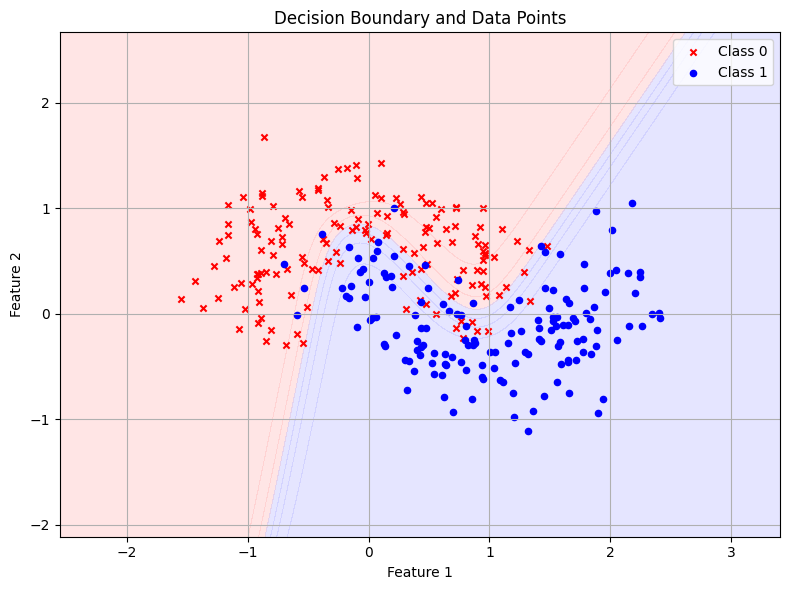

In [58]:
def plot_decision_boundary(
    X: np.ndarray, y: np.ndarray, model: MLP, resolution: float = 0.02
) -> None:
    # カラーマップ
    cmap_background = ListedColormap(["#FFAAAA", "#AAAAFF"])
    cmap_points = ListedColormap(["red", "blue"])

    # 座標範囲を定義
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution), np.arange(y_min, y_max, resolution)
    )

    # メッシュ全体に対して予測を実行し、領域を色分け
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_background)

    # データ点をマーカーでプロット
    for label, marker in zip([0, 1], ["x", "o"]):
        plt.scatter(
            X[y.reshape(-1) == label][:, 0],
            X[y.reshape(-1) == label][:, 1],
            c=cmap_points(label),
            marker=marker,
            label=f"Class {label}",
            s=20,
        )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary and Data Points")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_decision_boundary(x, t, model)